In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/sandbox_products.csv")

In [3]:
df.head()

,Product Name,Price,Rating,Availability,Product URL
0,Lightweight Probiotics,$155.62,4.0,In Stock,https://scrapingsandbox.com/product/1
1,Wireless LED Desk Lamp,$145.40,4.6,Out of Stock,https://scrapingsandbox.com/product/2
2,Deluxe Tea Collection,$185.01,3.5,In Stock,https://scrapingsandbox.com/product/3
3,Essential Tire Gauge,$70.86,3.6,Out of Stock,https://scrapingsandbox.com/product/4
4,Smart Carving Tools,$97.13,3.5,In Stock,https://scrapingsandbox.com/product/5


In [4]:
df.shape

(120, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  120 non-null    str    
 1   Price         120 non-null    str    
 2   Rating        120 non-null    float64
 3   Availability  120 non-null    str    
 4   Product URL   120 non-null    str    
dtypes: float64(1), str(4)
memory usage: 4.8 KB


In [6]:
df.isnull().sum()

Product Name    0
Price           0
Rating          0
Availability    0
Product URL     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Price"] = df["Price"].str.replace("$", "", regex=False).astype(float)

In [9]:
df["Price"].head()

0    155.62
1    145.40
2    185.01
3     70.86
4     97.13
Name: Price, dtype: float64

In [10]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [11]:
df["Rating"].head()

0    4.0
1    4.6
2    3.5
3    3.6
4    3.5
Name: Rating, dtype: float64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  120 non-null    str    
 1   Price         120 non-null    float64
 2   Rating        120 non-null    float64
 3   Availability  120 non-null    str    
 4   Product URL   120 non-null    str    
dtypes: float64(2), str(3)
memory usage: 4.8 KB


In [13]:
print("Total Products:", len(df))

print("Average Price:", df["Price"].mean())

print("Minimum Price:", df["Price"].min())

print("Maximum Price:", df["Price"].max())

Total Products: 120
Average Price: 104.79708333333333
Minimum Price: 6.22
Maximum Price: 204.29


In [14]:
df["Rating"].value_counts()

Rating
3.6    10
4.6     9
3.4     9
4.2     8
4.8     8
3.7     8
3.3     8
3.5     7
4.3     7
4.5     6
4.1     6
4.4     6
3.1     5
3.9     4
3.2     4
4.0     3
4.9     3
4.7     3
3.0     2
5.0     2
3.8     2
Name: count, dtype: int64

In [15]:
df["Rating"].value_counts().sort_index()

Rating
3.0     2
3.1     5
3.2     4
3.3     8
3.4     9
3.5     7
3.6    10
3.7     8
3.8     2
3.9     4
4.0     3
4.1     6
4.2     8
4.3     7
4.4     6
4.5     6
4.6     9
4.7     3
4.8     8
4.9     3
5.0     2
Name: count, dtype: int64

In [16]:
most_common_rating = df["Rating"].mode()[0]

print("Most common rating:", most_common_rating)

Most common rating: 3.6


In [17]:
df["Availability"].value_counts()


Availability
In Stock        102
Out of Stock     18
Name: count, dtype: int64

In [18]:
availability_percent = df["Availability"].value_counts(normalize=True) * 100

print(availability_percent)

Availability
In Stock        85.0
Out of Stock    15.0
Name: proportion, dtype: float64


In [19]:
import matplotlib.pyplot as plt

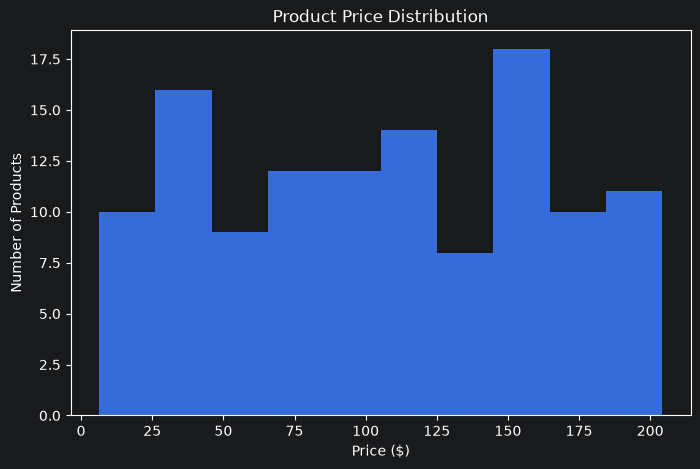

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=10)

plt.title("Product Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Number of Products")

plt.show()

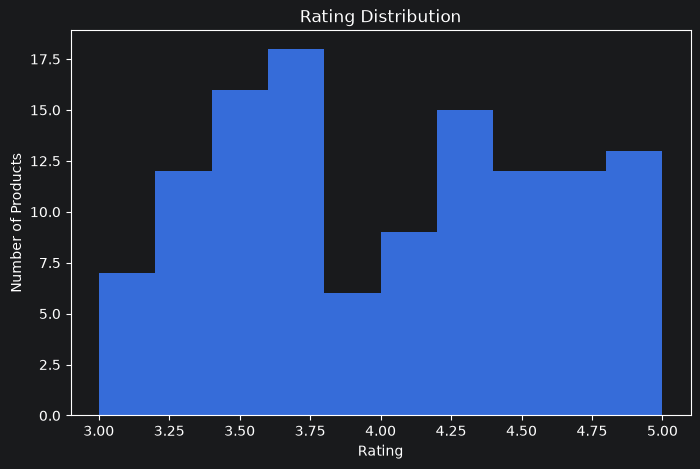

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(df["Rating"], bins=10)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.show()

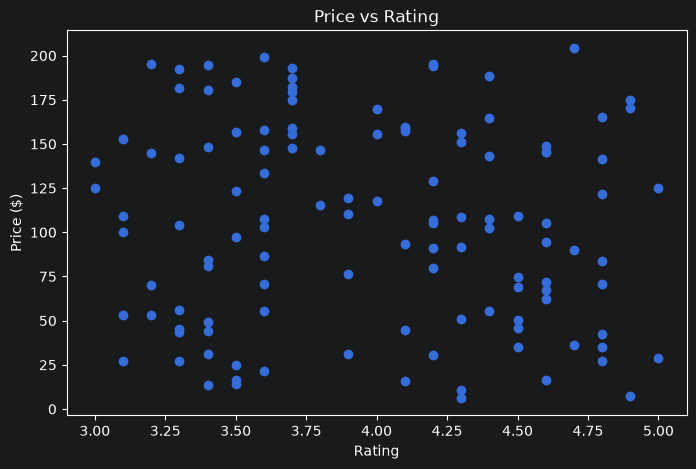

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Rating"], df["Price"])

plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price ($)")

plt.show()

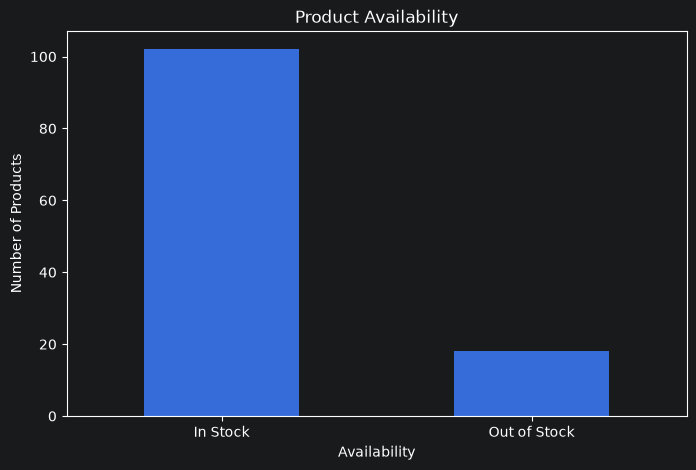

In [23]:
plt.figure(figsize=(8, 5))

df["Availability"].value_counts().plot(kind="bar")

plt.title("Product Availability")
plt.xlabel("Availability")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)

plt.show()

In [24]:
highest_rated = df.sort_values(
    by="Rating",
    ascending=False
).head(10)

highest_rated[[
    "Product Name",
    "Rating",
    "Price",
    "Availability"
]]

,Product Name,Rating,Price,Availability
14,Vintage Stuffed Animal,5.0,124.84,In Stock
119,Smart Cardigan,5.0,28.73,In Stock
28,Lightweight Blood Pressure Monitor,4.9,170.16,Out of Stock
18,Premium Business Book,4.9,175.14,In Stock
102,Smart Storage Basket,4.9,7.55,In Stock
77,Wireless Car Vacuum,4.8,42.41,In Stock
26,Premium Air Freshener,4.8,165.03,Out of Stock
20,Compact Heating Pad,4.8,70.83,In Stock
109,Classic Tennis Balls,4.8,83.72,In Stock
93,Compact Joggers,4.8,35.16,In Stock


In [25]:
lowest_priced = df.sort_values(
    by="Price",
    ascending=True
).head(10)

lowest_priced[[
    "Product Name",
    "Price",
    "Rating",
    "Availability"
]]

,Product Name,Price,Rating,Availability
76,Modern Coffee Beans,6.22,4.3,In Stock
102,Smart Storage Basket,7.55,4.9,In Stock
68,Lightweight Cardigan,11.02,4.3,In Stock
44,Handcrafted Chain,13.60,3.4,In Stock
90,Premium Seat Cover,14.00,3.5,In Stock
32,Classic First Aid Kit,15.69,4.1,In Stock
25,Pro Stamp Set,16.25,4.6,In Stock
79,Portable Planner,16.64,3.5,In Stock
70,Classic Canvas,21.25,3.6,In Stock
81,Portable Sneakers,24.83,3.5,In Stock


In [26]:
print("===== E-COMMERCE DATA ANALYSIS SUMMARY =====")

print("Total Products:", len(df))
print("Average Price: $", round(df["Price"].mean(), 2))
print("Minimum Price: $", round(df["Price"].min(), 2))
print("Maximum Price: $", round(df["Price"].max(), 2))

print("Most Common Rating:", df["Rating"].mode()[0])

print("\nAvailability:")
print(df["Availability"].value_counts())

print("\nHighest Rating:", df["Rating"].max())
print("Lowest Rating:", df["Rating"].min())

===== E-COMMERCE DATA ANALYSIS SUMMARY =====
Total Products: 120
Average Price: $ 104.8
Minimum Price: $ 6.22
Maximum Price: $ 204.29
Most Common Rating: 3.6

Availability:
Availability
In Stock        102
Out of Stock     18
Name: count, dtype: int64

Highest Rating: 5.0
Lowest Rating: 3.0


In [27]:
print("===== FINAL DATA VALIDATION =====")

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

===== FINAL DATA VALIDATION =====
Missing values:
Product Name    0
Price           0
Rating          0
Availability    0
Product URL     0
dtype: int64

Duplicate rows:
0

Data types:
Product Name        str
Price           float64
Rating          float64
Availability        str
Product URL         str
dtype: object


In [28]:
df.to_csv("../data/sandbox_products_cleaned.csv", index=False)

df.to_excel("../data/sandbox_products_cleaned.xlsx", index=False)

print("Cleaned CSV and Excel files saved successfully!")

Cleaned CSV and Excel files saved successfully!
